# Forcasting Harmonic Osscilators using a Physics Informed Neural Network in Pytorch


**Loading in librarys**

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Oscillators import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Generating training and testing data



In [2]:
m = 1.0
k = 1.0
A_0 = 1.0
v_0 = 0.0
b = 0.01
F_0 = 1
w_0 = 0.8


oscillator = Harmonic_Oscillator(
    mass=m,
    force_const=k,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=A_0,    # Start with same amplitude as driven oscillation
    velocity=v_0,             # Zero initial velocity for clean phase
    damping_const=b,       # Very light damping (γ = b/2m = 0.005)
    driving_force=F_0,
    driving_frequency=w_0    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)

points = 1000
t = np.linspace(0, 100, 1000)
x = oscillator.get_x_pos(t)

# normalising values around zero so work better in neural network
t_mean, t_std = float(t.mean()), float(t.std())
t_norm = (t-t_mean) / t_std

x_mean, x_std = float(x.mean()), float(x.std())
x_norm = (x-x_mean) / x_std




# two regimes: dense and forcast, dense just goes over all points and radomly selects `training values` numbers of points
# forcast splits it into a percentage so the data can be forcasted

regime = "dense"
forecast_split = 50.0

training_values = 100

np.random.seed(42)

if regime == "forecast":
    label_pool = np.where(t <= forecast_split)[0]
    forecast_index = np.where(t > forecast_split)[0]     # returns when elemnet is true in index one, and false in index 2
else:
    label_pool = np.arange(points)
    forecast_index = np.array([], dtype=int)

# without replacement and over the full pool - randint(0, points - 1) both
# duplicated indices and could never pick the final point
training_index = np.random.choice(label_pool, training_values, replace=False)

# unlabelled points inside the labelled window: interpolation error
interp_index = np.setdiff1d(label_pool, training_index)

print(f"regime={regime}  labels={len(training_index)} drawn from t<={t[label_pool].max():.1f}"
      f"  | interp points={len(interp_index)}  forecast points={len(forecast_index)}")


def gather(idx):
    return [t_norm[i] for i in idx], [x_norm[i] for i in idx]

training_data_t, training_data_x = gather(training_index)
interp_data_t,   interp_data_x   = gather(interp_index)
forecast_data_t, forecast_data_x = gather(forecast_index)


regime=dense  labels=100 drawn from t<=100.0  | interp points=900  forecast points=0


In [3]:
batch_size = 100


def as_tensor(vals):
    return torch.tensor(vals, dtype=torch.float32).reshape(-1, 1)


# Turned into a tensor to create data to be used in nn
training_data_t, training_data_x = as_tensor(training_data_t), as_tensor(training_data_x)
interp_data_t,   interp_data_x   = as_tensor(interp_data_t),   as_tensor(interp_data_x)
forecast_data_t, forecast_data_x = as_tensor(forecast_data_t), as_tensor(forecast_data_x)


training_dataset = TensorDataset(training_data_t, training_data_x)
interp_dataset   = TensorDataset(interp_data_t,   interp_data_x)
forecast_dataset = TensorDataset(forecast_data_t, forecast_data_x)

training_dataloader = DataLoader(training_dataset, shuffle=True, batch_size=batch_size)

# full-batch and unshuffled, so predictions as forcasting needs time order
# could maybe do windows if going for a longer dataset? 
# going to just incrementlay increase amound nn can view 
interp_dataloader = DataLoader(interp_dataset, batch_size=max(len(interp_dataset), 1))

forecast_dataloader = (DataLoader(forecast_dataset, batch_size=len(forecast_dataset))
                       if len(forecast_dataset) else None)

for X, y in training_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X: torch.Size([100, 1])
Shape of y: torch.Size([100, 1]) torch.float32


## Defining a model 

In [4]:
# Define model
hidden_neurons = 64

class NeuralNetwork(nn.Module):
    def __init__(self, hidden_neurons = 64):
        super().__init__()

        self.linear_tanh_stack = nn.Sequential(
            
            nn.Linear(1, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, 1)
        )

    def forward(self, t):

        logits = self.linear_tanh_stack(t)
        return logits



### Loss function


In [5]:

n_colloc = 2000 # number of poinst nn will be trained on through out the entire data set (remember x does not need to be known)
physics_const = 1 # represents proportion of the loss function being trained by physics const
basic_const = 1 # proportion trained be basic nn MSE(pred, expected)


def ode_residual(t_colloc, x_colloc):
    """Dimensionless residual of  m * d2x/dt2 + b * dx/dt + k * x - F_0 cos(w_0 t),
    given the network's normalised output x_colloc = x_norm(t_norm).
    """
    dxdt_norm = torch.autograd.grad(x_colloc, t_colloc, 
                               grad_outputs=torch.ones_like(x_colloc), # means doenst calculate arbritaty calculations between x_i and t_j thoughout nn (saves time)
                               create_graph=True)[0]

    d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc, 
                               grad_outputs=torch.ones_like(dxdt_norm),
                               create_graph=True)[0]

    # the network outputs x_norm as a function of t_norm, so undo BOTH
    # normalisations before the derivatives mean anything physically:
    #   x = x_norm * x_std + x_mean,  t = t_norm * t_std + t_mean
    # dx/dt    = dx_norm/dt_norm * x_std / t_std
    # d2x/dt2  = d2x_norm/dt_norm2 * x_std / t_std ** 2
    dxdt = dxdt_norm * x_std / t_std
    d2xdt2 = d2xdt2_norm * x_std / t_std ** 2

    x_phys = x_colloc * x_std + x_mean
    t_phys = t_colloc * t_std + t_mean

    # divided by F_0 so the residual is dimensionless and physics_const is O(1)
    return (m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)) / F_0


class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target, t_colloc, x_colloc):

        basic_loss = nn.functional.mse_loss(output, target)

        # also need it to fit to osccilator equation
        # can use any arbritary t, as we are not labling them with correct solution
        residual = ode_residual(t_colloc, x_colloc)
        colloc_loss = nn.functional.mse_loss(residual, torch.zeros_like(residual))

        return basic_const * basic_loss + physics_const * colloc_loss





## Training

In [6]:
t_lo, t_hi = float(t_norm.min()), float(t_norm.max())


def make_colloc(n, s_hi=None):
    """Creates tensor to device used, that  are random numbers between [0, 1),
        multiplied by the range to give the apropiate number of random colloction points"""
    hi = t_hi if s_hi is None else s_hi
    return (torch.rand(n, 1, device=device) * (hi - t_lo) + t_lo).requires_grad_(True)


def run_training(use_physics, epochs=8000, lr=1e-3, use_scheduler=True,
                 seed=0, log_every=500, curriculum=None):
    """Train a fresh network and return it.
    use_physics: bool, represents if PINN should be used
    curriculum: list, represents increasing size of periods model will be 
        trained over to help with forcasting (not normalised)
    """
    torch.manual_seed(seed)                 # identical init for both runs, so any
    model = NeuralNetwork().to(device) # same model used throughout training     # difference is down to the physics term
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CustomLoss() if use_physics else nn.MSELoss()

    if curriculum is None:
        curriculum = [float(t.max())]
    stages = [(T - t_mean) / t_std for T in curriculum]   # -> normalised time
    epochs_per_stage = epochs // len(stages)

    history = []
    for stage, s_hi in enumerate(stages):
        # learning rates need to be reset on each stages or CosineAnnealingLR make effects of later stages negligable
        for group in optimizer.param_groups:
            group["lr"] = lr
        scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs_per_stage) if use_scheduler else None)
        if len(stages) > 1:
            print(f"-- stage {stage+1}/{len(stages)}: t <= {curriculum[stage]:.1f}")

        for epoch in range(epochs_per_stage):
            model.train()
            for T, X in training_dataloader:
                T, X = T.to(device), X.to(device)

                # the data term is restricted to the current stage too, so early
                # stages aren't pulled by labels beyond where physics is enforced
                mask = (T <= s_hi).squeeze(-1)
                if mask.any():
                    data_pred, data_target = model(T[mask]), X[mask]
                else:
                    data_pred = data_target = None

                if use_physics:
                    t_colloc = make_colloc(n_colloc, s_hi)
                    x_colloc = model(t_colloc)
                    if data_pred is None:      # no labels yet in this window
                        residual = ode_residual(t_colloc, x_colloc)
                        loss = physics_const * nn.functional.mse_loss(
                            residual, torch.zeros_like(residual))
                    else:
                        loss = loss_fn(data_pred, data_target, t_colloc, x_colloc)
                else:
                    if data_pred is None:
                        continue               # nothing to learn from yet
                    loss = loss_fn(data_pred, data_target)

                # Backpropagation
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            if scheduler is not None:
                scheduler.step()

            history.append(loss.item())
            if epoch % log_every == 0 or epoch == epochs_per_stage - 1:



                print(f"epoch {epoch+1:>6}/{epochs_per_stage}  loss {loss.item():.6f}"
                      f"  lr {optimizer.param_groups[0]['lr']:.2e}")

    return model, history


def evaluate(model, dataloader, label=""):
    """Data MSE and physics residual reported SEPARATELY, so the basic and PINN
    runs are measured on the same scale whichever loss trained them. The combined
    training objective is not comparable between the two."""
    if dataloader is None:
        print(f"{label}  (no points in this region for regime={regime})")
        return None

    model.eval()

    sq, n = 0.0, 0
    with torch.no_grad():                   # the data term needs no graph...
        for T, X in dataloader:
            T, X = T.to(device), X.to(device)
            sq += nn.functional.mse_loss(model(T), X, reduction="sum").item()
            n += X.numel()
    data_mse = sq / n

    t_colloc = make_colloc(n_colloc)        # ...but the residual does
    physics_mse = ode_residual(t_colloc, model(t_colloc)).pow(2).mean().item()

    print(f"{label}  data MSE {data_mse:.6f}"
          f"  | RMSE {np.sqrt(data_mse) * x_std:.4f} (units of x)"
          f"  | physics residual MSE {physics_mse:.6f}")
    return {"data_mse": data_mse, "physics_mse": physics_mse}


### Training the basic network


In [7]:
model_basic, hist_basic = run_training(use_physics=False, epochs=1, lr=1e-3)

res_basic_i = evaluate(model_basic, interp_dataloader,   label="basic interp  ")
res_basic_f = evaluate(model_basic, forecast_dataloader, label="basic forecast")


epoch      1/1  loss 1.099510  lr 0.00e+00
basic interp    data MSE 1.017056  | RMSE 2.0794 (units of x)  | physics residual MSE 0.616439
basic forecast  (no points in this region for regime=dense)


### Training the PINN



In [8]:
model_pinn, hist_pinn = run_training(use_physics=True, epochs=40000, lr=1e-3,
                                     )

res_pinn_i = evaluate(model_pinn, interp_dataloader,   label="PINN  interp  ")
res_pinn_f = evaluate(model_pinn, forecast_dataloader, label="PINN  forecast")


epoch      1/40000  loss 1.831160  lr 1.00e-03
epoch    501/40000  loss 1.604941  lr 1.00e-03
epoch   1001/40000  loss 1.597048  lr 9.98e-04
epoch   1501/40000  loss 1.584675  lr 9.97e-04
epoch   2001/40000  loss 1.605509  lr 9.94e-04
epoch   2501/40000  loss 1.590053  lr 9.90e-04
epoch   3001/40000  loss 1.581167  lr 9.86e-04
epoch   3501/40000  loss 1.529263  lr 9.81e-04


KeyboardInterrupt: 

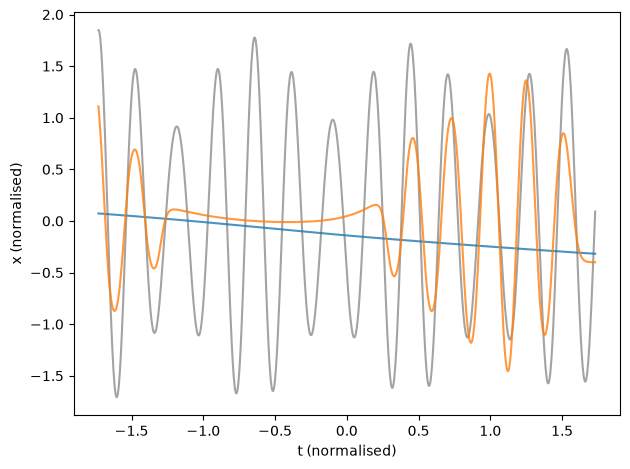

In [ ]:
### Plotting Results
t_grid = torch.tensor(t_norm, dtype=torch.float32).reshape(-1, 1).to(device)

# whichever training cells have been run
trained = {}
if "model_basic" in globals():
    trained["basic"] = (model_basic, hist_basic)
if "model_pinn" in globals():
    trained["PINN"] = (model_pinn, hist_pinn)

fig, ax = plt.subplots()

ax.plot(t_norm, x_norm, label="actual", color="0.4", alpha=0.6)
for name, (mdl, _) in trained.items():
    mdl.eval()
    with torch.no_grad():   
        pred = mdl(t_grid).cpu().squeeze()
    ax.plot(t_norm, pred, label=f"{name} prediction", alpha=0.8)

# the training points - gaps between them are where the fit is free to wander
# ax.scatter(t_norm[training_index], x_norm[training_index],
#           s=10, color="k", zorder=3, label="training points")


if len(forecast_index):
    s_split = (forecast_split - t_mean) / t_std
    ax.axvline(s_split, color="crimson", lw=1.2, ls="--")
    ax.axvspan(s_split, t_hi, color="crimson", alpha=0.07,
               label="forecast region (no labels)")

ax.set_xlabel("t (normalised)")
ax.set_ylabel("x (normalised)")
#ax.legend(loc="upper left", fontsize=8)


fig.tight_layout()
plt.savefig(f"no_training_points_2000_coloc_64_neurons_40000_epochs.pdf")


# Running Lots of data
Using Claude i got it to create a single run investigating the forcasting loss against epoch for: learning rate, number of hidden neurons, number of colloculation points and changes in how effectve the PINN loss funciton is, see what made the largest effect.

In [ ]:


import os
import time

SWEEP_EPOCHS = 20000            # epochs per run; raise (e.g. 40000) on a GPU machine
SWEEP_EVAL_EVERY = 200          # how often (in epochs) to record forecast loss
SWEEP_FORECAST_SPLIT = 50.0    # t <= split -> trainable region, t > split -> held-out forecast region
SWEEP_TRAINING_VALUES = 100    # number of labelled points drawn from the trainable region

SWEEP_DIR = "sweep_results2"
PLOT_DIR = os.path.join(SWEEP_DIR, "plots")
CSV_DIR = os.path.join(SWEEP_DIR, "csv")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

# ---- local forecast split, independent of the `regime` global set in the
# "Generating training and testing data" cell above ----
sweep_t_lo, sweep_t_hi = float(t_norm.min()), float(t_norm.max())

np.random.seed(42)
sweep_label_pool = np.where(t <= SWEEP_FORECAST_SPLIT)[0]
sweep_forecast_index = np.where(t > SWEEP_FORECAST_SPLIT)[0]
sweep_training_index = np.random.choice(sweep_label_pool, SWEEP_TRAINING_VALUES, replace=False)


def _sweep_gather(idx):
    ts = torch.tensor([t_norm[i] for i in idx], dtype=torch.float32).reshape(-1, 1)
    xs = torch.tensor([x_norm[i] for i in idx], dtype=torch.float32).reshape(-1, 1)
    return ts.to(device), xs.to(device)


sweep_train_t, sweep_train_x = _sweep_gather(sweep_training_index)
sweep_forecast_t, sweep_forecast_x = _sweep_gather(sweep_forecast_index)

print(f"[sweep] forecast split at t={SWEEP_FORECAST_SPLIT}: "
      f"{len(sweep_training_index)} training points, {len(sweep_forecast_index)} forecast points")


# ---- local, parameterised physics helpers (same maths as ode_residual /
# CustomLoss above, but physics_const is an explicit argument, not a global) ----

def sweep_ode_residual(t_colloc, x_colloc):
    dxdt_norm = torch.autograd.grad(x_colloc, t_colloc,
                                     grad_outputs=torch.ones_like(x_colloc),
                                     create_graph=True)[0]
    d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc,
                                       grad_outputs=torch.ones_like(dxdt_norm),
                                       create_graph=True)[0]
    dxdt = dxdt_norm * x_std / t_std
    d2xdt2 = d2xdt2_norm * x_std / t_std ** 2
    x_phys = x_colloc * x_std + x_mean
    t_phys = t_colloc * t_std + t_mean
    return (m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)) / F_0


def sweep_loss(data_pred, data_target, t_colloc, x_colloc, physics_const_val):
    basic_loss = nn.functional.mse_loss(data_pred, data_target)
    residual = sweep_ode_residual(t_colloc, x_colloc)
    colloc_loss = nn.functional.mse_loss(residual, torch.zeros_like(residual))
    return basic_loss + physics_const_val * colloc_loss


def sweep_make_colloc(n):
    return (torch.rand(n, 1, device=device) * (sweep_t_hi - sweep_t_lo) + sweep_t_lo).requires_grad_(True)


def train_one_config(hidden_neurons, lr, use_scheduler, n_colloc, physics_const_val,
                      epochs=SWEEP_EPOCHS, eval_every=SWEEP_EVAL_EVERY, seed=0):
    """Trains one PINN configuration (use_physics=True always), evaluating
    forecast-set data MSE every `eval_every` epochs. Returns
    (history: list[dict], final_metrics: dict), or (None, None) if the run
    diverged / errored (so the sweep can skip it and keep going)."""
    torch.manual_seed(seed)
    model = NeuralNetwork(hidden_neurons).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if use_scheduler else None)

    history = []
    try:
        for epoch in range(epochs):
            model.train()
            t_colloc = sweep_make_colloc(n_colloc)
            x_colloc = model(t_colloc)
            data_pred = model(sweep_train_t)
            loss = sweep_loss(data_pred, sweep_train_x, t_colloc, x_colloc, physics_const_val)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()

            if epoch % eval_every == 0 or epoch == epochs - 1:

                if not torch.isfinite(loss):
                    raise FloatingPointError(f"non-finite loss at epoch {epoch}: {loss.item()}")

                model.eval()
                with torch.no_grad():
                    forecast_mse = nn.functional.mse_loss(model(sweep_forecast_t), sweep_forecast_x).item()
                history.append({"epoch": epoch, "train_loss": loss.item(),
                                 "forecast_mse": forecast_mse})
    except Exception as e:
        print(f"    [FAILED] {e}")
        return None, None

    final = {"final_train_loss": history[-1]["train_loss"],
             "final_forecast_mse": history[-1]["forecast_mse"]}
    return history, final


# ---- sweep definition ----
DEFAULTS = dict(hidden_neurons=256, lr=1e-3, use_scheduler=True,
                 n_colloc=10000, physics_const=1.0)

sweep_groups = {
    "lr": {"values": [1e-1, 5e-2, 1e-2, 5e-3, 1e-3],
           "overrides": {"use_scheduler": False}},   # scheduler off for this group only
    "hidden_neurons": {"values": [256, 512, 1024], "overrides": {}},
    "n_colloc": {"values": [5000, 10000, 20000, 50000, 100000], "overrides": {}},
    "physics_const": {"values": [0.5, 1, 1.5, 2, 5], "overrides": {}},
}

summary_rows = []
sweep_start = time.time()

for group_name, group in sweep_groups.items():
    print(f"\n=== sweeping {group_name} ===")
    for value in group["values"]:
        cfg = dict(DEFAULTS)
        cfg.update(group["overrides"])
        cfg[group_name] = value

        run_label = f"{group_name}_{value}"
        print(f"  -> {run_label}: {cfg}")
        run_start = time.time()

        history, final = train_one_config(
            hidden_neurons=cfg["hidden_neurons"], lr=cfg["lr"],
            use_scheduler=cfg["use_scheduler"], n_colloc=cfg["n_colloc"],
            physics_const_val=cfg["physics_const"],
        )
        elapsed = time.time() - run_start
        success = history is not None

        if success:
            hist_df = pd.DataFrame(history)
            hist_df.to_csv(os.path.join(CSV_DIR, f"{run_label}.csv"), index=False)
            print(f"     done in {elapsed:.1f}s | final forecast MSE {final['final_forecast_mse']:.6f}")
        else:
            print(f"     failed after {elapsed:.1f}s")

        summary_rows.append({
            "group": group_name, "varied_value": value, **cfg,
            "epochs": SWEEP_EPOCHS, "success": success,
            "final_train_loss": final["final_train_loss"] if success else float("nan"),
            "final_forecast_mse": final["final_forecast_mse"] if success else float("nan"),
            "elapsed_seconds": elapsed,
        })
        # write summary incrementally, so partial sweeps aren't lost if interrupted
        pd.DataFrame(summary_rows).to_csv(os.path.join(CSV_DIR, "summary.csv"), index=False)

total_elapsed = time.time() - sweep_start
n_ok = sum(r["success"] for r in summary_rows)
print(f"\n=== sweep finished in {total_elapsed/60:.1f} min | {n_ok}/{len(summary_rows)} runs succeeded ===")

# ---- plotting: one figure per swept hyperparameter ----
for group_name, group in sweep_groups.items():
    fig, ax = plt.subplots()
    for value in group["values"]:
        run_label = f"{group_name}_{value}"
        csv_path = os.path.join(CSV_DIR, f"{run_label}.csv")
        if not os.path.exists(csv_path):
            continue
        hist_df = pd.read_csv(csv_path)
        ax.plot(hist_df["epoch"], hist_df["forecast_mse"], label=f"{group_name}={value}")

    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("forecast data MSE (log scale)")
    fixed = {k: v for k, v in DEFAULTS.items() if k != group_name}
    fixed.update(group["overrides"])
    ax.set_title(f"PINN forecast loss vs epoch — varying {group_name}\n(defaults: {fixed})", fontsize=9)
    ax.legend(fontsize=8)
    fig.tight_layout()

    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(PLOT_DIR, f"{group_name}_sweep_forecast_loss_vs_epoch.{ext}"))
    plt.close(fig)

print(f"Plots saved to {PLOT_DIR}/, CSVs saved to {CSV_DIR}/")


[sweep] forecast split at t=50.0: 100 training points, 500 forecast points

=== sweeping lr ===
  -> lr_0.1: {'hidden_neurons': 256, 'lr': 0.1, 'use_scheduler': False, 'n_colloc': 10000, 'physics_const': 1.0}
     done in 203.8s | final forecast MSE 2.174320
  -> lr_0.05: {'hidden_neurons': 256, 'lr': 0.05, 'use_scheduler': False, 'n_colloc': 10000, 'physics_const': 1.0}
     done in 205.5s | final forecast MSE 1.028059
  -> lr_0.01: {'hidden_neurons': 256, 'lr': 0.01, 'use_scheduler': False, 'n_colloc': 10000, 'physics_const': 1.0}
     done in 205.6s | final forecast MSE 0.035996
  -> lr_0.005: {'hidden_neurons': 256, 'lr': 0.005, 'use_scheduler': False, 'n_colloc': 10000, 'physics_const': 1.0}
     done in 205.7s | final forecast MSE 0.043848
  -> lr_0.001: {'hidden_neurons': 256, 'lr': 0.001, 'use_scheduler': False, 'n_colloc': 10000, 'physics_const': 1.0}
     done in 203.1s | final forecast MSE 0.032284

=== sweeping hidden_neurons ===
  -> hidden_neurons_256: {'hidden_neurons': 